### DOWNLOAD DATA

In [ ]:
#!pip install yfinance
import yfinance as yf
import pandas as pd

# Download S&P 500 index data (^GSPC) from 1990-01-01 to 2018-12-31
sp500 = yf.download("^GSPC", start="1990-01-01", end="2018-12-31", interval="1d")

# Save to CSV
sp500.to_csv("sp500_1990_2018.csv")

print("Saved S&P 500 data to sp500_1990_2018.csv")

# Save to CSV
sp500.to_csv("data/sp500_1990_2018.csv")

print("Saved S&P 500 data to sp500_1990_2018.csv")

# download and save VIX
vix = yf.download("^VIX", start="1990-01-01", end="2018-12-31",
                 interval="1d", auto_adjust=False, progress=False)

# Get the "Close" column for ticker ^VIX
vix_close = vix[("Close", "^VIX")].rename("VIX_Close")
vix_df = vix_close.to_frame()

vix_df.to_csv("data/vix_1990_2018.csv")

print("Saved VIX data to vix_1990_2018.csv")

### IMPORT INTO PANDAS FROM DISK

In [1]:
import pandas as pd
import numpy as np

# 1) Load exactly as-is
df = pd.read_csv("../data/raw data/sp500_1990_2018.csv")

# 2) Drop the two metadata rows: where 'Price' is 'Ticker' or 'Date'
df = df[~df["Price"].isin(["Ticker", "Date"])].copy()

# 3) Parse dates and set index
df["Date"] = pd.to_datetime(df["Price"])
df = df.drop(columns=["Price"]).set_index("Date").sort_index()

# 4) Make sure numeric cols are numeric
for c in ["Close","High","Low","Open","Volume"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# 5) Drop intra-day prices
df = df.drop(columns=["High", "Low", "Open"])

print(df.head())
print(df.dtypes)

                 Close     Volume
Date                             
1990-01-02  359.690002  162070000
1990-01-03  358.760010  192330000
1990-01-04  355.670013  177000000
1990-01-05  352.200012  158530000
1990-01-08  353.790009  140110000
Close     float64
Volume      int64
dtype: object


### CLEAN SPX DATA

In [2]:
import pandas as pd

# Load raw CSV
spx_raw = pd.read_csv("../data/raw data/sp500_1990_2018.csv")

# Drop the two junk rows ("Ticker", "Date")
spx_clean = spx_raw[~spx_raw["Price"].isin(["Ticker","Date"])].copy()

# Parse Date
spx_clean["Date"] = pd.to_datetime(spx_clean["Price"], errors="raise")
spx_clean = spx_clean.drop(columns=["Price"]).set_index("Date").sort_index()

# Ensure numeric types
for c in ["Close","High","Low","Open","Volume"]:
    if c in spx_clean.columns:
        spx_clean[c] = pd.to_numeric(spx_clean[c], errors="coerce")

#print(spx_clean.dtypes)
#print(spx_clean.head())

# Optional: sanity check for technical indicators
need_cols = ["Close","High","Low"]
assert all(c in spx_clean.columns for c in need_cols), "Missing OHLC columns."

spx_clean.head()

,Close,High,Low,Open,Volume
Date,,,,,
1990-01-02,359.690002,359.690002,351.980011,353.399994,162070000
1990-01-03,358.760010,360.589996,357.890015,359.690002,192330000
1990-01-04,355.670013,358.760010,352.890015,358.760010,177000000
1990-01-05,352.200012,355.670013,351.350006,355.670013,158530000
1990-01-08,353.790009,354.239990,350.540009,352.200012,140110000


### IMPORT & CLEAN VFX

In [3]:
vix = pd.read_csv("../data/raw data/vix_1990_2018.csv")  # or however you saved it

# Parse Date and set as index
vix["Date"] = pd.to_datetime(vix["Date"])
vix = vix.set_index("Date").sort_index()

print(vix.dtypes)
vix.head()

VIX_Close    float64
dtype: object


,VIX_Close
Date,
1990-01-02,17.240000
1990-01-03,18.190001
1990-01-04,19.219999
1990-01-05,20.110001
1990-01-08,20.260000


### IMPORT & CLEAN MOVE
The move metric began in 2002. Not sure why it's listed in the paper if it doesn't cover the entire training range. Will omit it from the model.

In [40]:
import pandas as pd
import yfinance as yf

START, END = "1990-02-12", "2018-10-05"

# 1) Download
mv = yf.download("^MOVE", start=START, end=END, interval="1d", auto_adjust=False, progress=False)

# 2) Inspect exactly what we got (no renaming yet)
print(type(mv), mv.shape)
print(mv.columns)     # often a MultiIndex: ('Close','^MOVE'), etc.
print(mv.index[:3], "...", mv.index[-3:])
print(mv.head())

# 3) Extract a plain Close series based on what you saw
if isinstance(mv.columns, pd.MultiIndex):
    move_close = mv[("Close", "^MOVE")].rename("MOVE_Close")
else:
    move_close = mv["Close"].rename("MOVE_Close")

# 4) Make it a tidy DataFrame with Date index
move = move_close.to_frame().copy()
move.index = pd.to_datetime(move.index)
move = move.sort_index()

print(move.dtypes)
print(move.head())

<class 'pandas.core.frame.DataFrame'> (3917, 6)
MultiIndex([('Adj Close', '^MOVE'),
            (    'Close', '^MOVE'),
            (     'High', '^MOVE'),
            (      'Low', '^MOVE'),
            (     'Open', '^MOVE'),
            (   'Volume', '^MOVE')],
           names=['Price', 'Ticker'])
DatetimeIndex(['2002-11-12', '2002-11-13', '2002-11-14'], dtype='datetime64[ns]', name='Date', freq=None) ... DatetimeIndex(['2018-10-02', '2018-10-03', '2018-10-04'], dtype='datetime64[ns]', name='Date', freq=None)
Price        Adj Close       Close        High         Low        Open Volume
Ticker           ^MOVE       ^MOVE       ^MOVE       ^MOVE       ^MOVE  ^MOVE
Date                                                                         
2002-11-12  120.209999  120.209999  120.209999  120.209999  120.209999      0
2002-11-13  122.879997  122.879997  122.879997  122.879997  122.879997      0
2002-11-14  130.289993  130.289993  130.289993  130.289993  130.289993      0
2002-11-15  1

### IMPORT & CLEAN ADS

In [4]:
import pandas as pd

ads = pd.read_excel("../data/raw data/ADS_Index_Most_Current_Vintage.xlsx")

# Rename columns
ads = ads.rename(columns={"Unnamed: 0": "Date"})

# Parse Date column
ads["Date"] = pd.to_datetime(ads["Date"], format="%Y:%m:%d")

# Set index
ads = ads.set_index("Date").sort_index()

# Keep only the research period (1990–2018)
ads = ads.loc["1990-01-01":"2018-12-31"]

print(ads.info())
print(ads.head())
print(ads.tail())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 10592 entries, 1990-01-01 to 2018-12-31
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ADS_Index  10592 non-null  float64
 1   RECBARS    10592 non-null  int64  
dtypes: float64(1), int64(1)
memory usage: 248.2 KB
None
            ADS_Index  RECBARS
Date                          
1990-01-01  -0.178398        0
1990-01-02  -0.196996        0
1990-01-03  -0.213842        0
1990-01-04  -0.228943        0
1990-01-05  -0.242304        0
            ADS_Index  RECBARS
Date                          
2018-12-27  -0.230603        0
2018-12-28  -0.239467        0
2018-12-29  -0.248664        0
2018-12-30  -0.258198        0
2018-12-31  -0.269100        0


### IMPORT & CLEAN FRED RATES

In [9]:
import pandas_datareader.data as pdr

START, END = "1990-02-12", "2018-10-05"
codes = ["DFF","DTB3","DGS10","DGS30","DAAA","DBAA","TEDRATE"]
rates = pdr.DataReader(codes, "fred", START, END)
#peek(rates, "Rates/Yields/TED (raw)")

# Rename for clarity
rates = rates.rename(columns={
    "DFF":"FedFunds", "DTB3":"TBill3M", "DGS10":"Govt10Y", "DGS30":"Govt30Y",
    "DAAA":"Aaa", "DBAA":"Baa", "TEDRATE":"TED"
})

# Spreads & daily deltas exactly like appendix
rates_feat = pd.DataFrame(index=rates.index)
rates_feat["fft"]   = rates["FedFunds"].diff()       # Fed funds change
rates_feat["3mth"]  = rates["TBill3M"].diff()
rates_feat["10yr"]  = rates["Govt10Y"].diff()
rates_feat["30yr"]  = rates["Govt30Y"].diff()
rates_feat["Aaa"]   = rates["Aaa"].diff()
rates_feat["Baa"]   = rates["Baa"].diff()
rates_feat["term_spread"]  = rates["Govt10Y"] - rates["TBill3M"]
rates_feat["long_spread"]  = rates["Govt30Y"] - rates["Govt10Y"]
rates_feat["corp_spread"]  = rates["Baa"] - rates["Aaa"]
rates_feat["Aaa_minus_10Y"]= rates["Aaa"] - rates["Govt10Y"]
rates_feat["TED"]          = rates["TED"]  # paper lists TED separately
#peek(rates_feat, "Rates features (clean-ish)")

### IMPORT & CLEAN Exchange rates (FRED)

In [10]:
from pandas_datareader import data as pdr
import numpy as np
import pandas as pd

START, END = "1990-01-01", "2018-12-31"

# Download major currencies (goods only)
fx_raw = pdr.DataReader("DTWEXM", "fred", START, END)

# Clean into a neat DataFrame
fx = pd.DataFrame(index=fx_raw.index)
fx["majcurr_level"] = fx_raw["DTWEXM"]
fx["majcurr_ret"] = np.log(fx["majcurr_level"]).diff()

# Drop rows with missing values at the start
fx = fx.dropna()

print(fx.info())
print(fx.head())
print(fx.tail())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 7139 entries, 1990-01-03 to 2018-12-31
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   majcurr_level  7139 non-null   float64
 1   majcurr_ret    7139 non-null   float64
dtypes: float64(2)
memory usage: 167.3 KB
None
            majcurr_level  majcurr_ret
DATE                                  
1990-01-03        93.2095     0.001500
1990-01-04        91.9952    -0.013113
1990-01-05        91.9587    -0.000397
1990-01-08        91.6824    -0.003009
1990-01-09        92.1002     0.004547
            majcurr_level  majcurr_ret
DATE                                  
2018-12-21        92.1151     0.001841
2018-12-24        92.1151     0.000000
2018-12-27        92.2298     0.002178
2018-12-28        91.9394    -0.003154
2018-12-31        91.7941    -0.001582


### IM[PRT & CLEAN OTHER STOCK MARKET DATA

In [11]:
import pandas as pd
import numpy as np
import yfinance as yf

START, END = "1990-01-01", "2018-12-31"

# Be explicit about auto_adjust to silence the warning
dax_raw  = yf.download("^GDAXI", start=START, end=END, interval="1d", auto_adjust=True, progress=False)
ftse_raw = yf.download("^FTSE",  start=START, end=END, interval="1d", auto_adjust=True, progress=False)

def close_series(df, ticker_label, out_name):
    # Works for both MultiIndex and flat columns
    if isinstance(df.columns, pd.MultiIndex):
        s = df.xs("Close", level=0, axis=1)
        # If still DataFrame (e.g., one column), squeeze to Series
        if isinstance(s, pd.DataFrame):
            # prefer exact ticker match; otherwise first column
            if ticker_label in s.columns:
                s = s[ticker_label]
            else:
                s = s.iloc[:, 0]
    else:
        s = df["Close"]
    s = s.rename(out_name)
    return s.to_frame()

dax  = close_series(dax_raw,  "^GDAXI", "DAX")
ftse = close_series(ftse_raw, "^FTSE",  "FTSE")

# Ensure tz-naive + sorted
for df in (dax, ftse):
    if getattr(df.index, "tz", None) is not None:
        df.index = df.index.tz_localize(None)
    df.sort_index(inplace=True)

# Log returns
rdax  = np.log(dax["DAX"]).diff().rename("rdax").to_frame().dropna()
rftse = np.log(ftse["FTSE"]).diff().rename("rftse").to_frame().dropna()

# Sanity checks
print("DAX level:",  dax.index.min().date(),  "→", dax.index.max().date(),  "| rows:", len(dax))
print("FTSE level:", ftse.index.min().date(), "→", ftse.index.max().date(), "| rows:", len(ftse))
print("rdax:",  rdax.shape,  " NaNs:", rdax.isna().sum().sum())
print("rftse:", rftse.shape, " NaNs:", rftse.isna().sum().sum())
print(dax.head(), "\n", ftse.head())
print(rdax.head(), "\n", rftse.head())

DAX level: 1990-01-02 → 2018-12-28 | rows: 7328
FTSE level: 1990-01-02 → 2018-12-28 | rows: 7325
rdax: (7327, 1)  NaNs: 0
rftse: (7324, 1)  NaNs: 0
                    DAX
Date                   
1990-01-02  1788.890015
1990-01-03  1867.290039
1990-01-04  1830.920044
1990-01-05  1812.900024
1990-01-08  1841.469971 
                    FTSE
Date                   
1990-01-02  2434.100098
1990-01-03  2463.699951
1990-01-04  2451.600098
1990-01-05  2444.500000
1990-01-08  2431.300049
                rdax
Date                
1990-01-03  0.042893
1990-01-04 -0.019670
1990-01-05 -0.009891
1990-01-08  0.015636
1990-01-09  0.012976 
                rftse
Date                
1990-01-03  0.012087
1990-01-04 -0.004923
1990-01-05 -0.002900
1990-01-08 -0.005414
1990-01-09  0.002054


### IMPORT & CLEAN COMMODITIES

In [12]:
gold = pd.read_csv("../data/raw data/gold_daily_lbma_1990_2018.csv")

# Parse date and set as index
gold["Date"] = pd.to_datetime(gold["date"])
gold = gold.set_index("Date").sort_index()

# Keep only gold_usd
gold = gold[["gold_usd"]].rename(columns={"gold_usd": "Gold"})

print(gold.info())
print(gold.head())
print(gold.tail())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 7273 entries, 1990-01-02 to 2018-12-28
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Gold    7273 non-null   float64
dtypes: float64(1)
memory usage: 113.6 KB
None
             Gold
Date             
1990-01-02  399.0
1990-01-03  395.0
1990-01-04  396.5
1990-01-05  405.0
1990-01-08  404.6
               Gold
Date               
2018-12-19  1255.00
2018-12-20  1259.75
2018-12-21  1258.15
2018-12-27  1268.00
2018-12-28  1279.00


In [13]:
silver = pd.read_csv("../data/raw data/silver_daily_lbma_1990_2018.csv")

# Parse date and set as index
silver["Date"] = pd.to_datetime(silver["date"])
silver = silver.set_index("Date").sort_index()

# Keep only gold_usd
silver = silver[["silver_usd"]].rename(columns={"silver_usd": "Silver"})

print(gold.info())
print(gold.head())
print(gold.tail())
silver.head()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 7273 entries, 1990-01-02 to 2018-12-28
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Gold    7273 non-null   float64
dtypes: float64(1)
memory usage: 113.6 KB
None
             Gold
Date             
1990-01-02  399.0
1990-01-03  395.0
1990-01-04  396.5
1990-01-05  405.0
1990-01-08  404.6
               Gold
Date               
2018-12-19  1255.00
2018-12-20  1259.75
2018-12-21  1258.15
2018-12-27  1268.00
2018-12-28  1279.00


,Silver
Date,
1990-01-02,5.210
1990-01-03,5.160
1990-01-04,5.196
1990-01-05,5.280
1990-01-08,5.280


In [15]:
import pandas as pd
import numpy as np
import yfinance as yf  # keep if you use it elsewhere

START, END = "1990-01-01", "2018-12-31"

# ---------- WTI (CSV: observation_date, DCOILWTICO) ----------
wti_raw = pd.read_csv("../data/raw data/DCOILWTICO.csv")
print("WTI preview:\n", wti_raw.head(), "\n")

wti = (
    wti_raw.rename(columns={"observation_date": "Date", "DCOILWTICO": "WTI"})
           .assign(Date=lambda df: pd.to_datetime(df["Date"]))
           .set_index("Date")["WTI"]
           .replace(".", np.nan)
           .astype(float)
           .sort_index()
      ).loc[START:END]

oil = np.log(wti).diff().rename("oil")
print("WTI range:", (wti.index.min(), wti.index.max()), "| rows:", wti.shape[0])
print(oil.dropna().head(), "\n")

# ---------- Copper (monthly, USD/metric ton, CSV: observation_date, PCOPPUSDM) ----------
# --- Copper (monthly → daily on SPX trading days) ---
copper_m = (
    pd.read_csv("../data/raw data/PCOPPUSDM.csv")
      .rename(columns={"observation_date": "Date", "PCOPPUSDM": "Copper"})
      .assign(Date=lambda df: pd.to_datetime(df["Date"]))
      .set_index("Date")
      .loc["1990-01-01":"2018-12-31"]
)

# 1) Union SPX + monthly dates so 1990-01-01 exists during the fill
# 2) Sort, forward-fill, then slice back to SPX trading days
copper_daily = (
    copper_m.reindex(spx_clean.index.union(copper_m.index))
             .sort_index()
             .ffill()
             .loc[spx_clean.index]
)

# Daily log-returns on the SPX calendar
copper_daily["copper_ret"] = np.log(copper_daily["Copper"]).diff()

print(copper_daily.info())
print(copper_daily.head())

# ---------- Final: join on SPX calendar ----------
# Align OIL to SPX trading days
oil_df = oil.reindex(spx_clean.index).to_frame('oil')

# Use the DAILY copper you created (forward-filled), not the old monthly frame
# Recompute copper_ret AFTER alignment so it’s daily too
copper_daily_aligned = copper_daily.reindex(spx_clean.index)
copper_daily_aligned['copper_ret'] = np.log(copper_daily_aligned['Copper']).diff()

# Final commodity block on SPX calendar
commod = oil_df.join(copper_daily_aligned[['Copper', 'copper_ret']], how='left')

# Quick sanity checks
print(commod[['oil','Copper','copper_ret']].info())
print(commod.head())
print(commod[['Copper','copper_ret']].iloc[:15])

WTI preview:
   observation_date  DCOILWTICO
0       1986-01-02       25.56
1       1986-01-03       26.00
2       1986-01-06       26.53
3       1986-01-07       25.85
4       1986-01-08       25.87 

WTI range: (Timestamp('1990-01-01 00:00:00'), Timestamp('2018-12-31 00:00:00')) | rows: 7566
Date
1990-01-03    0.039842
1990-01-04   -0.016942
1990-01-05   -0.014630
1990-01-08   -0.063990
1990-01-09    0.027799
Name: oil, dtype: float64 

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 7306 entries, 1990-01-02 to 2018-12-28
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Copper      7306 non-null   float64
 1   copper_ret  7305 non-null   float64
dtypes: float64(2)
memory usage: 171.2 KB
None
                 Copper  copper_ret
Date                               
1990-01-02  2365.556991         NaN
1990-01-03  2365.556991         0.0
1990-01-04  2365.556991         0.0
1990-01-05  2365.556991         0.0
1990-0

### INDICATORS

In [16]:
import numpy as np
import pandas as pd

# Work from the cleaned S&P500 data
px = spx_clean.copy()

# Sanity: ensure datetime index
if not isinstance(px.index, pd.DatetimeIndex):
    px.index = pd.to_datetime(px.index)

# --- Parameters ---
n = 10

# --- Returns ---
px["ret"] = np.log(px["Close"]).diff()

# --- Moving Average (MA_n) ---
px["MA10"] = px["Close"].rolling(n).mean()

# --- Momentum (P_t - P_{t-(n-1)}) ---
px["MOM10"] = px["Close"] - px["Close"].shift(n-1)

# --- Stochastic %K and %D ---
Hn = px["High"].rolling(n).max()
Ln = px["Low"].rolling(n).min()
rng = (Hn - Ln).replace(0, np.nan)
px["StochK"] = (px["Close"] - Ln) / rng * 100
px["StochD"] = px["StochK"].rolling(n).mean()

# --- RSI (n=10) ---
delta = px["Close"].diff()
up   = delta.clip(lower=0).rolling(n-1).sum()
down = (-delta.clip(upper=0)).rolling(n-1).sum()
px["RSI"] = 100 * (up / (up + down))

# --- Williams %R ---
px["Rperc"] = (Hn - px["Close"]) / rng * 100

# --- MACD (12,26) and signal (9) ---
ema12 = px["Close"].ewm(span=12, adjust=False).mean()
ema26 = px["Close"].ewm(span=26, adjust=False).mean()
px["MACD"]    = ema12 - ema26
px["MACDsig"] = px["MACD"].ewm(span=9, adjust=False).mean()

# --- Final feature frame ---
tech = px[["ret","MA10","MOM10","StochK","StochD","RSI","Rperc","MACD","MACDsig"]]

print(tech.info())
print(tech.dropna().head())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 7306 entries, 1990-01-02 to 2018-12-28
Data columns (total 9 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   ret      7305 non-null   float64
 1   MA10     7297 non-null   float64
 2   MOM10    7297 non-null   float64
 3   StochK   7297 non-null   float64
 4   StochD   7288 non-null   float64
 5   RSI      7297 non-null   float64
 6   Rperc    7297 non-null   float64
 7   MACD     7306 non-null   float64
 8   MACDsig  7306 non-null   float64
dtypes: float64(9)
memory usage: 570.8 KB
None
                 ret        MA10      MOM10     StochK     StochD        RSI  \
Date                                                                           
1990-01-26 -0.000859  333.661996 -11.200012  21.195838  16.068316  27.291110   
1990-01-29 -0.001843  332.481998 -15.549988  18.279088  17.717210  13.853964   
1990-01-30 -0.006850  330.704999 -14.419983  14.202079  16.426174  14.622123   
1990-01-31 

### MERGE INTO ONE DF

In [24]:
dfs = [vix, spx_clean, ads, rates_feat, fx, dax, rdax, ftse,
       gold, silver, commod, tech]

merged = pd.concat(dfs, axis=1, join="outer")

# --- Compute gold/silver returns inside merged, then drop level columns ---

# Calculate log-returns from the raw Gold and Silver price columns
if "Gold" in merged.columns:
    merged["gold_ret"] = np.log(merged["Gold"]).diff()

if "Silver" in merged.columns:
    merged["silver_ret"] = np.log(merged["Silver"]).diff()

# Drop the unused level/price columns
cols_to_drop = ["majcurr_level", "Copper", "Gold", "Silver"]
merged = merged.drop(columns=cols_to_drop, errors="ignore")

# Sanity check
print("Columns now include:", [c for c in merged.columns if "gold" in c or "silver" in c])
print(merged[["gold_ret", "silver_ret"]].head())
print(merged.info())

# Drop unnecessary level columns, keep only return-based features
cols_to_drop = ["majcurr_level", "Copper", "Gold", "Silver"]
merged = merged.drop(columns=cols_to_drop, errors="ignore")

print(merged.info())
print(merged.head())

Columns now include: ['gold_ret', 'silver_ret']
            gold_ret  silver_ret
1990-01-01       NaN         NaN
1990-01-02       NaN         NaN
1990-01-03 -0.010076   -0.009643
1990-01-04  0.003790    0.006953
1990-01-05  0.021211    0.016037
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 10592 entries, 1990-01-01 to 2018-12-31
Freq: D
Data columns (total 36 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   VIX_Close      7306 non-null   float64
 1   Close          7306 non-null   float64
 2   High           7306 non-null   float64
 3   Low            7306 non-null   float64
 4   Open           7306 non-null   float64
 5   Volume         7306 non-null   float64
 6   ADS_Index      10592 non-null  float64
 7   RECBARS        10592 non-null  int64  
 8   fft            10462 non-null  float64
 9   3mth           5596 non-null   float64
 10  10yr           5596 non-null   float64
 11  30yr           5596 non-null   float64
 12 

### LAGGED INDICATORS

In [25]:
# %% vectorized, no fragmentation, no duplicate _lag1
# Assumes `merged` exists; we won't touch target 'ret' here.

base = merged  # just a short alias

# 1) 1-day lag for *all* predictors except the target
lag1 = base.drop(columns=["ret"], errors="ignore").shift(1)
lag1.columns = [f"{c}_lag1" for c in lag1.columns]

# 2) 2- and 3-day lags for the reduced-6 predictors (skip lag1 here to avoid dupes)
reduced6 = ["VIX_Close", "MACD", "term_spread", "corp_spread", "majcurr_ret", "DAX"]
present6 = [c for c in reduced6 if c in base.columns]

lag23 = pd.concat(
    [base[c].shift(l).rename(f"{c}_lag{l}") for c in present6 for l in (2, 3)],
    axis=1
)

# 3) join everything at once (no fragmentation); keep original cols + lags
lagged_df = pd.concat([base, lag1, lag23], axis=1)

print("Before creating lagged features:")
print("Shape:", merged.shape)
print("Example columns:", list(merged.columns[:15]))

print("\nAfter creating lagged features (concat once, no fragmentation):")
print("Shape:", lagged_df.shape)
print("Example lag1 cols (first 12):", [c for c in lagged_df.columns if c.endswith("_lag1")][:12])

merged = lagged_df  # keep your original variable name

Before creating lagged features:
Shape: (10592, 36)
Example columns: ['VIX_Close', 'Close', 'High', 'Low', 'Open', 'Volume', 'ADS_Index', 'RECBARS', 'fft', '3mth', '10yr', '30yr', 'Aaa', 'Baa', 'term_spread']

After creating lagged features (concat once, no fragmentation):
Shape: (10592, 83)
Example lag1 cols (first 12): ['VIX_Close_lag1', 'Close_lag1', 'High_lag1', 'Low_lag1', 'Open_lag1', 'Volume_lag1', 'ADS_Index_lag1', 'RECBARS_lag1', 'fft_lag1', '3mth_lag1', '10yr_lag1', '30yr_lag1']


### CLEAN
- drops non-trading days
- forward fill missing vals

In [26]:
# ---------- Align & fill strategy (SPX calendar + warm-up + internal gaps only) ----------
# 1) Align everything to SPX trading days
X = merged.reindex(spx_clean.index)

# 2) Warm-up: only fix the first N rows' *leading* NaNs by backfilling within that window
N = 30  # adjust if you want a different warm-up size
X = X.copy()
X.iloc[:N] = X.iloc[:N].bfill()  # carry earliest available values backward *within* the first N rows

# 3) Fill only *internal* gaps (i.e., between two valid values). 
#    This leaves any remaining leading/trailing NaNs intact.
X = X.ffill(limit_area="inside")

# ---------- Quick sanity checks ----------
print("Rows/cols:", X.shape)

# NaNs in the first 10 rows (after warm-up)
print("Start window missing per col (first 10 rows):")
print(X.iloc[:10].isna().sum())

# Any NaNs remaining *after* the warm-up window?
has_nans_afterN = X.iloc[N:].isna().any().any()
print("\nAny NaNs outside the warm-up window?:", has_nans_afterN)

# If any remain, show counts to see which columns still have gaps
if has_nans_afterN:
    na_counts_afterN = X.iloc[N:].isna().sum()
    print("\nNaN counts after warm-up (by column):")
    print(na_counts_afterN[na_counts_afterN > 0].sort_values(ascending=False))

# Peek a few rows
print("\nHead:")
print(X.head(3))
print("\nAround warm-up boundary:")
print(X.iloc[max(0, N-2):N+2])

Rows/cols: (7306, 83)
Start window missing per col (first 10 rows):
VIX_Close            0
Close                0
High                 0
Low                  0
Open                 0
                    ..
corp_spread_lag3    10
majcurr_ret_lag2     0
majcurr_ret_lag3     0
DAX_lag2             0
DAX_lag3             0
Length: 83, dtype: int64

Any NaNs outside the warm-up window?: True

NaN counts after warm-up (by column):
Baa_lag1              58
corp_spread_lag3      58
corp_spread_lag2      58
term_spread_lag3      58
term_spread_lag2      58
fft_lag1              58
3mth_lag1             58
10yr_lag1             58
30yr_lag1             58
Aaa_lag1              58
fft                   57
TED_lag1              57
Aaa_minus_10Y_lag1    57
corp_spread_lag1      57
long_spread_lag1      57
3mth                  57
term_spread_lag1      57
TED                   57
10yr                  57
corp_spread           57
long_spread           57
term_spread           57
Aaa_minus_10Y        

In [27]:
# 3) Fill only *internal* gaps using BOTH directions (no leading/trailing touch)
#    This handles isolated holes where a forward fill alone can’t reach.
X = X.bfill(limit_area="inside").ffill(limit_area="inside")

# ---------- Sanity checks (unchanged) ----------
print("Rows/cols:", X.shape)
print("Start window missing per col (first 10 rows):")
print(X.iloc[:10].isna().sum())

has_nans_afterN = X.iloc[N:].isna().any().any()
print("\nAny NaNs outside the warm-up window?:", has_nans_afterN)

if has_nans_afterN:
    na_counts_afterN = X.iloc[N:].isna().sum()
    print("\nNaN counts after warm-up (by column):")
    print(na_counts_afterN[na_counts_afterN > 0].sort_values(ascending=False))

Rows/cols: (7306, 83)
Start window missing per col (first 10 rows):
VIX_Close            0
Close                0
High                 0
Low                  0
Open                 0
                    ..
corp_spread_lag3    10
majcurr_ret_lag2     0
majcurr_ret_lag3     0
DAX_lag2             0
DAX_lag3             0
Length: 83, dtype: int64

Any NaNs outside the warm-up window?: True

NaN counts after warm-up (by column):
Baa_lag1              58
corp_spread_lag3      58
corp_spread_lag2      58
term_spread_lag3      58
term_spread_lag2      58
fft_lag1              58
3mth_lag1             58
10yr_lag1             58
30yr_lag1             58
Aaa_lag1              58
fft                   57
TED_lag1              57
Aaa_minus_10Y_lag1    57
corp_spread_lag1      57
long_spread_lag1      57
3mth                  57
term_spread_lag1      57
TED                   57
10yr                  57
corp_spread           57
long_spread           57
term_spread           57
Aaa_minus_10Y        

In [28]:
# --- Targeted fill for columns still NaN after warm-up ---
N = 30  # same as before
afterN = X.iloc[N:]

# which columns still have NaNs after the warm-up window?
cols_still_nan = afterN.columns[afterN.isna().any()].tolist()
print("Columns with NaNs after warm-up:", cols_still_nan)

# backfill leading gaps up to the first valid, and ffill any trailing tail
for c in cols_still_nan:
    s = X[c].copy()

    # 1) fill leading block up to first valid obs
    fv = s.first_valid_index()
    if fv is not None:
        s.loc[:fv] = s.loc[:fv].bfill()

    # 2) fill internal gaps (if any remain)
    s = s.bfill(limit_area="inside").ffill(limit_area="inside")

    # 3) fill any trailing block from last valid obs to end
    lv = s.last_valid_index()
    if lv is not None:
        s.loc[lv:] = s.loc[lv:].ffill()

    X[c] = s

# sanity checks
print("\nAny NaNs outside the warm-up window now?:", X.iloc[N:].isna().any().any())
left = X.iloc[N:].isna().sum()
left = left[left > 0].sort_values(ascending=False)
if not left.empty:
    print("\nRemaining NaNs after warm-up (by column):")
    print(left)
else:
    print("\nAll clear after warm-up window.")

Columns with NaNs after warm-up: ['fft', '3mth', '10yr', '30yr', 'Aaa', 'Baa', 'term_spread', 'long_spread', 'corp_spread', 'Aaa_minus_10Y', 'TED', 'fft_lag1', '3mth_lag1', '10yr_lag1', '30yr_lag1', 'Aaa_lag1', 'Baa_lag1', 'term_spread_lag1', 'long_spread_lag1', 'corp_spread_lag1', 'Aaa_minus_10Y_lag1', 'TED_lag1', 'gold_ret_lag1', 'silver_ret_lag1', 'VIX_Close_lag3', 'MACD_lag3', 'term_spread_lag2', 'term_spread_lag3', 'corp_spread_lag2', 'corp_spread_lag3', 'majcurr_ret_lag2', 'majcurr_ret_lag3', 'DAX_lag2', 'DAX_lag3']

Any NaNs outside the warm-up window now?: False

All clear after warm-up window.


In [30]:
# %%
# Drop 1990 rows (paper excluded first year after lag construction)
X = X[X.index.year != 1990].copy()

print("After dropping 1990 rows:")
print("Date range:", X.index.min(), "→", X.index.max())
print("Rows remaining:", len(X))

After dropping 1990 rows:
Date range: 1991-01-02 00:00:00 → 2018-12-28 00:00:00
Rows remaining: 7053


In [31]:
# quick double-check
print(X.isna().sum().sum())  # should be 0

# save
X.to_csv("../data/raw data/merged_features_clean.csv", index=True)

0


### Base features, next-day returns, and train/test split

- Load cleaned merged SPX feature data and parse the Date column.
- Remove raw OHLCV fields; the **target** is defined as the next-day log return (`ret.shift(-1)`).
- Current-day features stay in `F`; no shuffling, chronological split at 2007-01-01.
- Compute Q1/Q3 thresholds **using training data only**, then label all days into {-1,0,1}.
- Drop any rows (within each split) where either features or labels contain NaNs.
- Print shapes and class balances; store the Q1/Q3 thresholds for later use.

In [11]:
import numpy as np
import pandas as pd

# --- inputs: X is your merged feature DF on SPX trading days and includes 'ret' ---
SPLIT_DATE = pd.Timestamp("2007-01-01")

df = pd.read_csv("../data/raw data/merged_features_clean.csv")
df["Date"] = pd.to_datetime(df["Date"], utc=False, errors="coerce")
df = df.drop(columns=["Close", "High", "Low", "Open", "Volume"])

# Target = NEXT-DAY log return (shift up by one day)
y = df["ret"].shift(-1)

# Features exclude 'ret' (stay at time t)
F = df.drop(columns=["ret"])

# Train/test masks (no shuffling)
train_mask = df["Date"] < SPLIT_DATE
test_mask  = ~train_mask

# --- Quantiles from TRAIN ONLY (on next-day returns) ---
q1, q3 = y[train_mask].quantile([0.25, 0.75])
print(f"Train Q1={q1:.6f}, Q3={q3:.6f}")

# --- Fixed-threshold labeling for ALL DATES ---
y_lbl = pd.Series(np.select(
    condlist=[y <= q1, y >= q3],
    choicelist=[-1, 1],
    default=0
), index=y.index)
y_lbl[y.isna()] = np.nan  # preserve missing labels (last row after shift)

# --- Split ---
X_train, y_train = F[train_mask], y_lbl[train_mask]
X_test,  y_test  = F[test_mask],  y_lbl[test_mask]

# --- Drop NaNs within each split (features or label) ---
train_keep = X_train.dropna().index.intersection(y_train.dropna().index)
test_keep  = X_test.dropna().index.intersection(y_test.dropna().index)

X_train, y_train = X_train.loc[train_keep], y_train.loc[train_keep]
X_test,  y_test  = X_test.loc[test_keep],  y_test.loc[test_keep]

# --- Quick sanity checks ---
print("\nShapes:")
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test: ", X_test.shape,  "y_test: ", y_test.shape)

print("\nClass balance (train):")
print(y_train.value_counts().sort_index())

print("\nClass balance (test):")
print(y_test.value_counts().sort_index())

# If you want the thresholds for later use:
Q_THRESHOLDS = {"q1": float(q1), "q3": float(q3)}
print("\nSaved thresholds:", Q_THRESHOLDS)

y_test.to_csv("../data/y_test_quartile.csv", index=True)
print("Saved quartile y_test to ../data/y_test_quartile.csv")

y_train.to_csv("../data/y_train_quartile.csv", index=True)
print("Saved quartile y_train to ../data/y_train_quartile.csv")

Train Q1=-0.004524, Q3=0.005529

Shapes:
X_train: (4034, 78) y_train: (4034,)
X_test:  (3018, 78) y_test:  (3018,)

Class balance (train):
-1.0    1009
 0.0    2016
 1.0    1009
Name: count, dtype: int64

Class balance (test):
-1.0     715
 0.0    1549
 1.0     754
Name: count, dtype: int64

Saved thresholds: {'q1': -0.00452374504280965, 'q3': 0.005529346059291725}
Saved quartile y_test to ../data/y_test_quartile.csv
Saved quartile y_train to ../data/y_train_quartile.csv


### Conditional complementary percentile labels (five threshold schemes)

- Compute **train-only** negative-side and positive-side quantiles using next-day returns.
- For each percentile *p* in {10%, 30%, 50%, 70%, 90%}, compute a paired threshold:
  - low threshold = p-quantile of **negative** returns  
  - high threshold = (1-p)-quantile of **positive** returns  
- Create label columns of the form `y_cond_comp_pXX_neg_posYY` using:
  - label = –1 if return ≤ low  
  - label = +1 if return ≥ high  
  - label = 0 otherwise  
- Add all new Y-columns to the full DataFrame (train + test aligned on original index).
- Print each (low, high) threshold pair and the class counts for train/test splits.

In [5]:
# --- Conditional complementary percentile labels: (neg p, pos 1-p) ---
percentiles = [0.10, 0.30, 0.50, 0.70, 0.90]

# Train-only returns
y_train_only = y[train_mask].dropna()
neg_train = y_train_only[y_train_only < 0]
pos_train = y_train_only[y_train_only > 0]

# Quantiles within each side
neg_q = neg_train.quantile(percentiles)                   # index: 0.10, 0.30, ...
pos_q = pos_train.quantile([1 - p for p in percentiles])  # index: 0.90, 0.70, ...

# Build (low, high) threshold pairs keyed by the negative percentile
pairs = {
    f"p{int(p*100)}_neg_pos{int((1-p)*100)}": (float(neg_q.loc[p]), float(pos_q.loc[1 - p]))
    for p in percentiles
}

def _label_by_thresholds(series, low, high):
    lbl = pd.Series(
        np.select([series <= low, series >= high], [-1, 1], default=0),
        index=series.index,
        dtype="int8",
    )
    lbl[series.isna()] = np.nan
    return lbl

# Create new Y columns on the full index (train+test), aligned with y
for key, (low, high) in pairs.items():
    col = f"y_cond_comp_{key}"  # e.g., y_cond_comp_p10_neg_pos90
    df[col] = _label_by_thresholds(y, low, high)

# Optional: print the thresholds and quick class balance (train/test) for each
print("\nConditional complementary thresholds (train-only derived):")
for key, (low, high) in pairs.items():
    print(f"{key:>18}: low={low:+.6f}, high={high:+.6f}")

print("\nClass balance by scheme (train / test):")
for key in pairs.keys():
    col = f"y_cond_comp_{key}"
    tr_counts = df.loc[train_mask, col].value_counts(dropna=True).sort_index()
    te_counts = df.loc[~train_mask, col].value_counts(dropna=True).sort_index()
    print(f"{col}: train {tr_counts.to_dict()} | test {te_counts.to_dict()}")


Conditional complementary thresholds (train-only derived):
     p10_neg_pos90: low=-0.016079, high=+0.015151
     p30_neg_pos70: low=-0.008379, high=+0.008497
     p50_neg_pos50: low=-0.004938, high=+0.005144
     p70_neg_pos30: low=-0.002627, high=+0.002616
      p90_neg_pos9: low=-0.000892, high=+0.000835

Class balance by scheme (train / test):
y_cond_comp_p10_neg_pos90: train {-1.0: 191, 0.0: 3630, 1.0: 213} | test {-1.0: 212, 0.0: 2613, 1.0: 193}
y_cond_comp_p30_neg_pos70: train {-1.0: 571, 0.0: 2824, 1.0: 639} | test {-1.0: 471, 0.0: 2059, 1.0: 488}
y_cond_comp_p50_neg_pos50: train {-1.0: 951, 0.0: 2018, 1.0: 1065} | test {-1.0: 683, 0.0: 1534, 1.0: 801}
y_cond_comp_p70_neg_pos30: train {-1.0: 1331, 0.0: 1212, 1.0: 1491} | test {-1.0: 924, 0.0: 945, 1.0: 1149}
y_cond_comp_p90_neg_pos9: train {-1.0: 1711, 0.0: 406, 1.0: 1917} | test {-1.0: 1210, 0.0: 354, 1.0: 1454}


### Build per-threshold train/test datasets for all label schemes

- Identify all conditional complementary label columns (`y_cond_comp_*`) in the main DataFrame.
- For each scheme, create **train/test splits** of features (`X_train_full`, `X_test_full`)
  using the same chronological masks as before.
- Within each split, keep only rows where **both** features and that scheme’s label are
  non-null; store aligned `X_train, y_train, X_test, y_test` in a `datasets` dict.
- Print, for every scheme, the shapes of X/y in train and test plus per-class counts
  to verify that each derived dataset is internally consistent.

In [6]:
# === Build per-threshold datasets using existing splits/features ===
# Assumes you've already added columns like: y_cond_comp_p10_neg_pos90, etc.

# 1) Identify label columns (adjust the prefix if you used a different naming pattern)
label_cols = [c for c in df.columns if c.startswith("y_cond_comp_")]

# 2) Precompute NaN-free feature indices per split (reuse across schemes)
X_train_full = F[train_mask]
X_test_full  = F[test_mask]
feat_ok_train_idx = X_train_full.dropna().index
feat_ok_test_idx  = X_test_full.dropna().index

# 3) Assemble datasets per label scheme
datasets = {}  # key: label_col -> dict with X_train, y_train, X_test, y_test
for col in label_cols:
    y_tr = df.loc[train_mask, col]
    y_te = df.loc[test_mask,  col]

    # Keep rows where BOTH features and label are non-null
    keep_tr = feat_ok_train_idx.intersection(y_tr.dropna().index)
    keep_te = feat_ok_test_idx.intersection(y_te.dropna().index)

    X_tr = X_train_full.loc[keep_tr]
    y_tr = y_tr.loc[keep_tr].astype("int8")

    X_te = X_test_full.loc[keep_te]
    y_te = y_te.loc[keep_te].astype("int8")

    datasets[col] = {"X_train": X_tr, "y_train": y_tr,
                     "X_test": X_te, "y_test": y_te}

# 4) Quick report
print("Datasets created for label schemes:\n")
for col, d in datasets.items():
    tr_counts = d["y_train"].value_counts().sort_index().to_dict()
    te_counts = d["y_test"].value_counts().sort_index().to_dict()
    print(f"{col}:")
    print(f"  train X:{d['X_train'].shape} y:{d['y_train'].shape}  class={tr_counts}")
    print(f"  test  X:{d['X_test'].shape}  y:{d['y_test'].shape}  class={te_counts}")

Datasets created for label schemes:

y_cond_comp_p10_neg_pos90:
  train X:(4034, 78) y:(4034,)  class={-1: 191, 0: 3630, 1: 213}
  test  X:(3018, 78)  y:(3018,)  class={-1: 212, 0: 2613, 1: 193}
y_cond_comp_p30_neg_pos70:
  train X:(4034, 78) y:(4034,)  class={-1: 571, 0: 2824, 1: 639}
  test  X:(3018, 78)  y:(3018,)  class={-1: 471, 0: 2059, 1: 488}
y_cond_comp_p50_neg_pos50:
  train X:(4034, 78) y:(4034,)  class={-1: 951, 0: 2018, 1: 1065}
  test  X:(3018, 78)  y:(3018,)  class={-1: 683, 0: 1534, 1: 801}
y_cond_comp_p70_neg_pos30:
  train X:(4034, 78) y:(4034,)  class={-1: 1331, 0: 1212, 1: 1491}
  test  X:(3018, 78)  y:(3018,)  class={-1: 924, 0: 945, 1: 1149}
y_cond_comp_p90_neg_pos9:
  train X:(4034, 78) y:(4034,)  class={-1: 1711, 0: 406, 1: 1917}
  test  X:(3018, 78)  y:(3018,)  class={-1: 1210, 0: 354, 1: 1454}


### Saving all feature matrices and label variants to disk

- Write the full feature matrices `X_train_full` and `X_test_full` (before any per-scheme
  NaN filtering) to `../data/X_train.csv` and `../data/X_test.csv`.
- For each conditional label scheme, save its aligned `y_train` and `y_test` vectors with
  filenames like `y_train_cond_comp_p10_neg_pos90.csv`.
- These saved `y_*` files correspond to **clean, NaN-filtered label rows**, but the saved
  `X_train.csv` / `X_test.csv` do **not** reflect that filtering.
- This creates the downstream mismatch: `X_test.csv` has **3019 rows**, while all
  `y_test_*` files have **3018 rows**.

In [8]:
# === Save all datasets to disk (aligned X/y) ===
from pathlib import Path

out_root = Path("../data")

# 1) Pick one label scheme as canonical for X indices.
#    All datasets[col]["X_train"] / ["X_test"] share the same aligned indices.
first_col = next(iter(datasets.keys()))
X_train_aligned = datasets[first_col]["X_train"].sort_index()
X_test_aligned  = datasets[first_col]["X_test"].sort_index()

# Save *aligned* X (no extra NaN row at the end of test)
X_train_aligned.to_csv(out_root / "X_train.csv", index=True)
X_test_aligned.to_csv(out_root / "X_test.csv", index=True)
print(f"Saved aligned X_train / X_test using indices from: {first_col}")
print("X_train shape:", X_train_aligned.shape)
print("X_test  shape:", X_test_aligned.shape)

# 2) Save each label variant (as before; these are already aligned to X indices)
for col, d in datasets.items():
    tag = col.replace("y_", "")  # e.g. cond_comp_p50_neg_pos50
    y_train_path = out_root / f"y_train_{tag}.csv"
    y_test_path  = out_root / f"y_test_{tag}.csv"
    d["y_train"].sort_index().to_csv(y_train_path, index=True, header=True)
    d["y_test"].sort_index().to_csv(y_test_path,  index=True, header=True)
    print(f"Saved {tag}: train->{y_train_path.name}, test->{y_test_path.name}")

print("\nAll label variants + aligned X_train/X_test saved to ../data/")

Saved aligned X_train / X_test using indices from: y_cond_comp_p10_neg_pos90
X_train shape: (4034, 78)
X_test  shape: (3018, 78)
Saved cond_comp_p10_neg_pos90: train->y_train_cond_comp_p10_neg_pos90.csv, test->y_test_cond_comp_p10_neg_pos90.csv
Saved cond_comp_p30_neg_pos70: train->y_train_cond_comp_p30_neg_pos70.csv, test->y_test_cond_comp_p30_neg_pos70.csv
Saved cond_comp_p50_neg_pos50: train->y_train_cond_comp_p50_neg_pos50.csv, test->y_test_cond_comp_p50_neg_pos50.csv
Saved cond_comp_p70_neg_pos30: train->y_train_cond_comp_p70_neg_pos30.csv, test->y_test_cond_comp_p70_neg_pos30.csv
Saved cond_comp_p90_neg_pos9: train->y_train_cond_comp_p90_neg_pos9.csv, test->y_test_cond_comp_p90_neg_pos9.csv

All label variants + aligned X_train/X_test saved to ../data/


In [7]:
# %%
import numpy as np
import pandas as pd

# ---- Load the same base data you used when building labels ----
SPLIT_DATE = pd.Timestamp("2007-01-01")
DATA_PATH  = "../data/raw data/merged_features_clean.csv"  # same path as before

df = pd.read_csv(DATA_PATH)
df["Date"] = pd.to_datetime(df["Date"], utc=False, errors="coerce")
df = df.drop(columns=["Close", "High", "Low", "Open", "Volume"], errors="ignore")

# Next-day return target (matches your pipeline)
if "ret" not in df.columns:
    raise KeyError("Expected a 'ret' column in the merged dataframe.")
y = df["ret"].shift(-1)

# Train/test masks
train_mask = df["Date"] < SPLIT_DATE

# ---- Split TRAIN returns into negative and positive subsets (drop NaNs) ----
neg_train = y[train_mask & (y < 0)].dropna()
pos_train = y[train_mask & (y > 0)].dropna()

if len(neg_train) == 0 or len(pos_train) == 0:
    raise ValueError("Train split has no negative or no positive returns; check data prep.")

# Helper: percentile within negatives vs. positives
def q_neg(pct):  # pct in {10,30,50,70,90,25,75}
    return float(np.quantile(neg_train, pct/100.0))
def q_pos(pct):
    return float(np.quantile(pos_train, pct/100.0))

# ---- Compute cutoffs for each scheme (NEG side uses pct_left, POS side uses pct_right) ----
schemes = {
    "p10_neg_pos90": (10, 90),
    "p30_neg_pos70": (30, 70),
    "p50_neg_pos50": (50, 50),
    "p70_neg_pos30": (70, 30),
    "p90_neg_pos10": (90, 10),
    "paper_p25_p75": (25, 75),  # paper reference
}

rows = []
for name, (lo_pct, hi_pct) in schemes.items():
    lo_val = q_neg(lo_pct)  # from NEGATIVE returns only
    hi_val = q_pos(hi_pct)  # from POSITIVE returns only
    rows.append({
        "scheme": name,
        "neg_pct": lo_pct,
        "neg_cutoff": lo_val,   # should be < 0
        "pos_pct": hi_pct,
        "pos_cutoff": hi_val,   # should be > 0
    })

out = pd.DataFrame(rows).set_index("scheme")
print("=== Conditional (within-sign) percentile cutoffs on TRAIN next-day returns ===")
print(out.to_string(float_format=lambda x: f"{x:+.6f}"))

# ---- Quick sanity checks ----
assert (out["neg_cutoff"] < 0).all(), "Found a non-negative NEG cutoff — check logic."
assert (out["pos_cutoff"] > 0).all(), "Found a non-positive POS cutoff — check logic."

# Optional: monotonicity sanity (more extreme percentiles should be farther from zero)
# For negatives: 10th <= 30th <= 50th <= 70th <= 90th < 0 (increasing toward 0)
neg_order = [10,30,50,70,90]
neg_vals  = [q_neg(p) for p in neg_order]
if not all(x <= y for x, y in zip(neg_vals, neg_vals[1:])):
    print("Warning: NEG monotonicity check failed (distribution quirks or ties)")

# For positives: 10th <= 30th <= 50th <= 70th <= 90th > 0 (increasing away from 0)
pos_order = [10,30,50,70,90]
pos_vals  = [q_pos(p) for p in pos_order]
if not all(x <= y for x, y in zip(pos_vals, pos_vals[1:])):
    print("Warning: POS monotonicity check failed (distribution quirks or ties)")

=== Conditional (within-sign) percentile cutoffs on TRAIN next-day returns ===
               neg_pct  neg_cutoff  pos_pct  pos_cutoff
scheme                                                 
p10_neg_pos90       10   -0.016079       90   +0.015151
p30_neg_pos70       30   -0.008379       70   +0.008497
p50_neg_pos50       50   -0.004938       50   +0.005144
p70_neg_pos30       70   -0.002627       30   +0.002616
p90_neg_pos10       90   -0.000892       10   +0.000835
paper_p25_p75       25   -0.009679       75   +0.009588


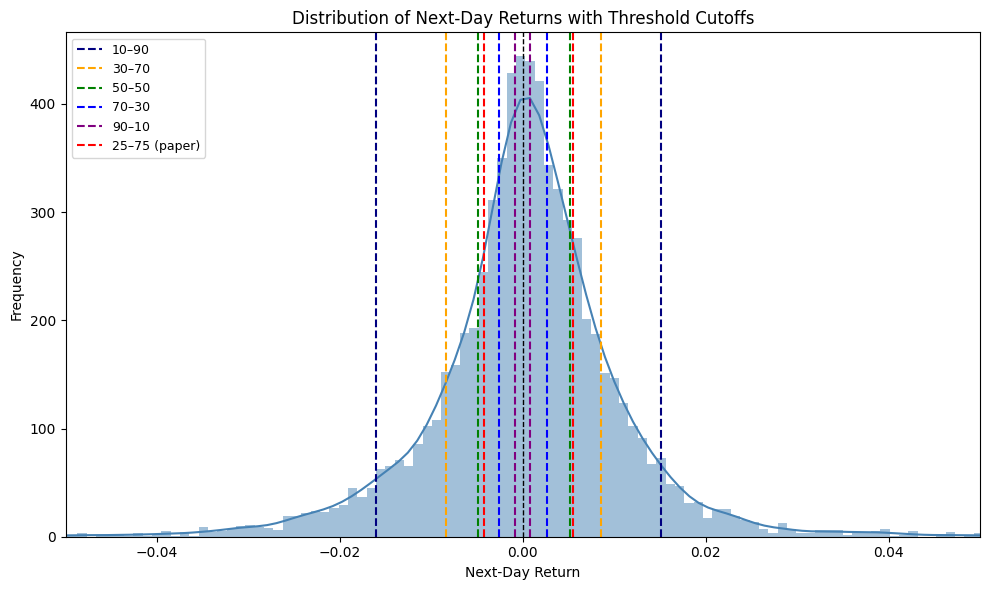

In [13]:
# %%
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Histogram base
returns = y.dropna()

plt.figure(figsize=(10,6))
sns.histplot(
    returns,
    bins=200,
    kde=True,
    color="steelblue",
    edgecolor=None
)
plt.axvline(0, color="black", linestyle="--", linewidth=1)

# === Threshold values per scheme ===
cutoffs = {
    "10–90":  (-0.016079, +0.015151),
    "30–70":  (-0.008379, +0.008497),
    "50–50":  (-0.004938, +0.005144),
    "70–30":  (-0.002627, +0.002616),
    "90–10":  (-0.000892, +0.000835),
    "25–75 (paper)": (-0.0043, +0.0055)
}

# === Updated colors ===
colors = {
    "10–90":  "navy",        # changed from red → navy
    "30–70":  "orange",
    "50–50":  "green",
    "70–30":  "blue",
    "90–10":  "purple",
    "25–75 (paper)": "red"   # remains red
}

# Plot all cutoffs
for label, (low, high) in cutoffs.items():
    color = colors[label]
    plt.axvline(low,  color=color, linestyle="--", linewidth=1.5)
    plt.axvline(high, color=color, linestyle="--", linewidth=1.5, label=f"{label}")

plt.title("Distribution of Next-Day Returns with Threshold Cutoffs")
plt.xlabel("Next-Day Return")
plt.ylabel("Frequency")
plt.xlim(-0.05, 0.05)
plt.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

In [1]:
# %% Diagnostics: which test row(s) were excluded when building the 3018-row test sets?

import numpy as np
import pandas as pd

# Rebuild as in your dataset notebook
X_test_full = F[test_mask]
y_te_any    = df.loc[test_mask, "y_cond_comp_p50_neg_pos50"]  # any label col works

feat_ok_test_idx = X_test_full.dropna().index
label_ok_idx     = y_te_any.dropna().index

keep_te = feat_ok_test_idx.intersection(label_ok_idx)

print("len(X_test_full):", len(X_test_full))
print("len(keep_te):    ", len(keep_te))

missing_idx = sorted(set(X_test_full.index) - set(keep_te))
print("\nIndices in X_test_full that were NOT used in X_te/y_te:", missing_idx)

# If you have a Date column in df:
date_cols = [c for c in df.columns if c.lower() == "date"]
if date_cols:
    dcol = date_cols[0]
    print("\nMissing row(s) and their dates:")
    print(df.loc[missing_idx, [dcol]])
else:
    print("\nNo Date column found in df; inspect missing_idx manually.")

NameError: name 'F' is not defined